# Hierarchical Clustering

## Problem Statement

The objective of this notebook is to segment customers into different groups using Hierarchical Clustering.

Hierarchical clustering is an unsupervised machine learning algorithm that creates clusters by building a hierarchy of data points.

### Dataset

Mall Customers Dataset

### Goal

- Perform Exploratory Data Analysis
- Preprocess customer data
- Build Hierarchical Clustering model
- Identify optimal number of clusters
- Evaluate clusters using Silhouette Score
- Visualize customer segments

In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
df.shape

(200, 5)

In [14]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [16]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [17]:
df.dtypes

CustomerID                int64
Genre                       str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [18]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [33]:
df.columns

Index(['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

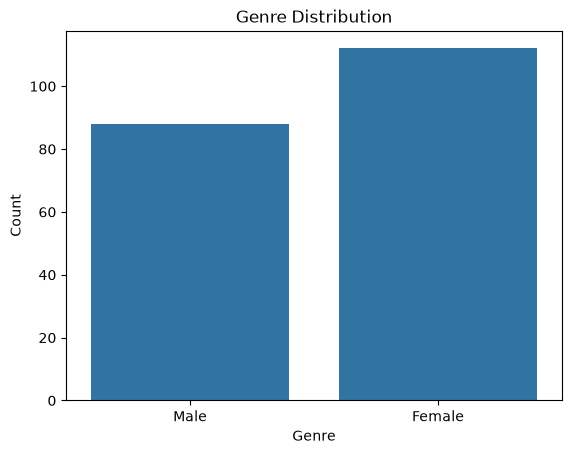

In [34]:
sns.countplot(
    x='Genre',
    data=df
)

plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

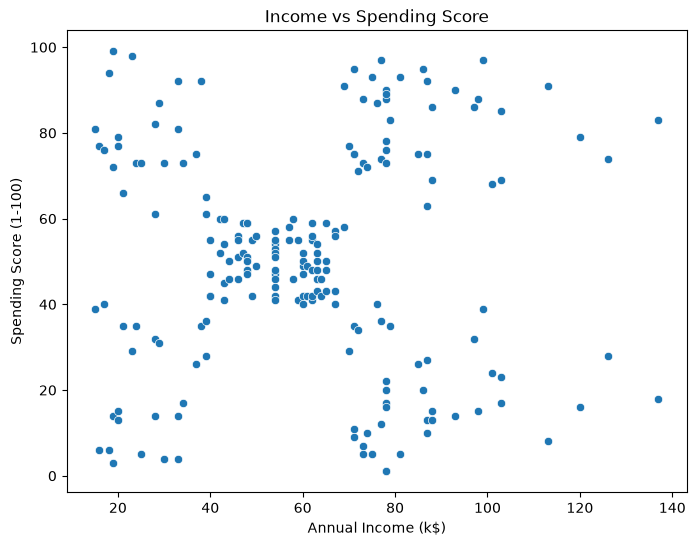

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title(
    "Income vs Spending Score"
)

plt.show()

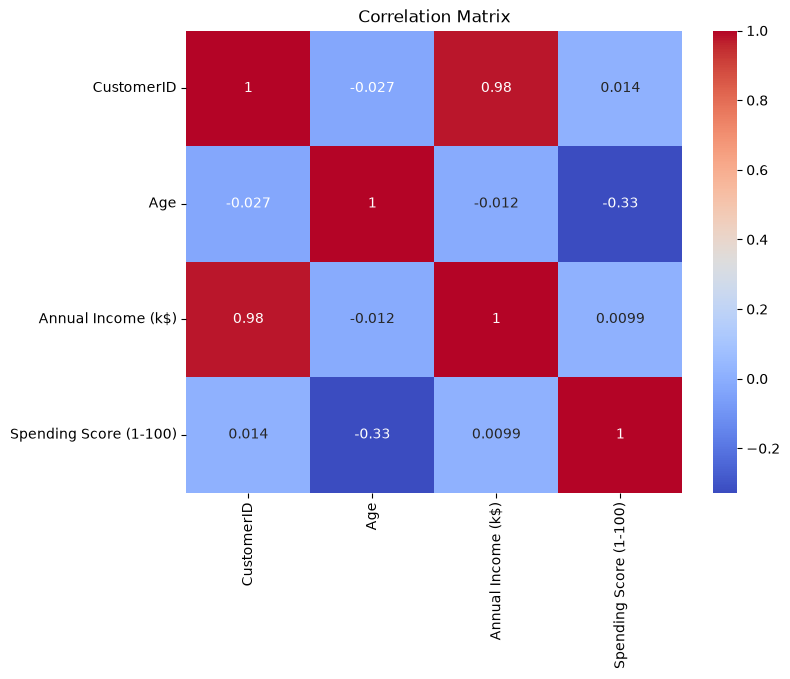

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [22]:
df.drop(
    'CustomerID',
    axis=1,
    inplace=True
)

In [35]:
df['Genre'] = df['Genre'].map({
    'Male':0,
    'Female':1
})

In [37]:
X = df[
    [
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
]

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

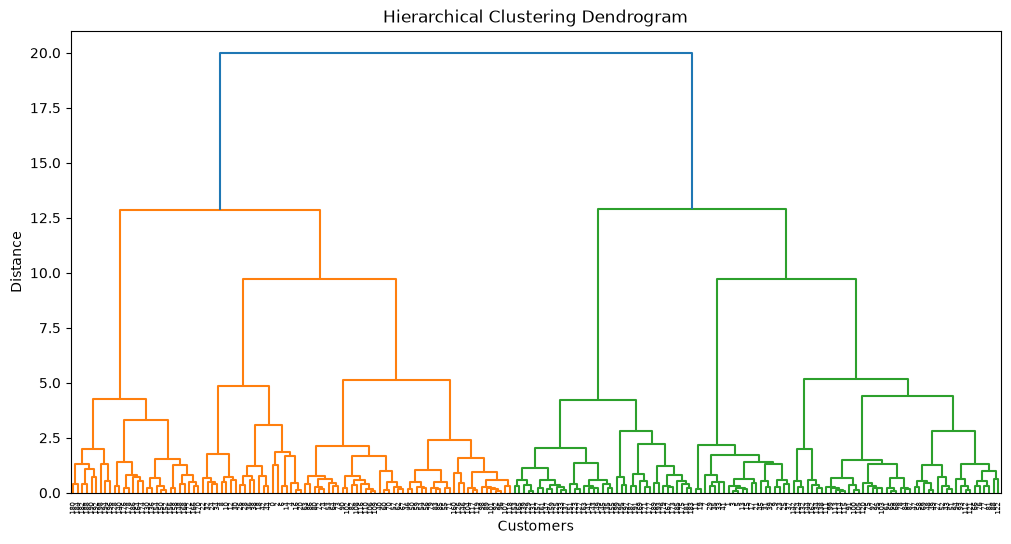

In [39]:
plt.figure(figsize=(12,6))


linkage_matrix = linkage(
    X_scaled,
    method='ward'
)


dendrogram(
    linkage_matrix
)


plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Customers")

plt.ylabel("Distance")

plt.show()

In [40]:
hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

In [41]:
clusters = hc.fit_predict(
    X_scaled
)

In [42]:
df['Cluster'] = clusters

df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,4
1,0,21,15,81,0
2,1,20,16,6,4
3,1,23,16,77,0
4,1,31,17,40,4


In [43]:
sil_score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "Silhouette Score:",
    sil_score
)

Silhouette Score: 0.39002826186267214


In [44]:
silhouette_scores=[]


for k in range(2,11):

    model = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage='ward'
    )

    labels=model.fit_predict(
        X_scaled
    )


    score=silhouette_score(
        X_scaled,
        labels
    )


    silhouette_scores.append(score)

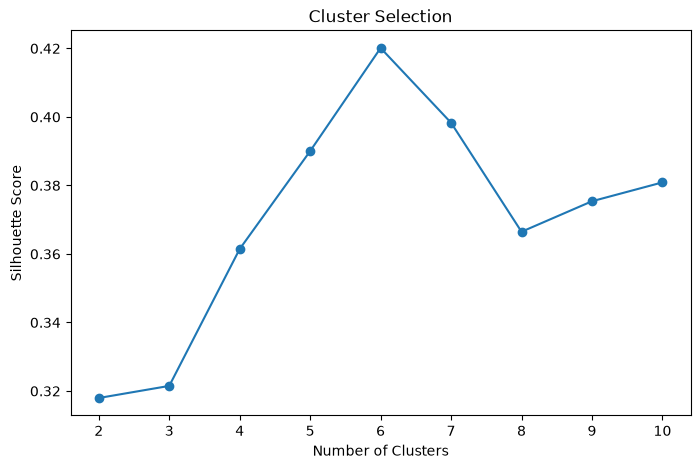

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Cluster Selection"
)

plt.show()

In [46]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

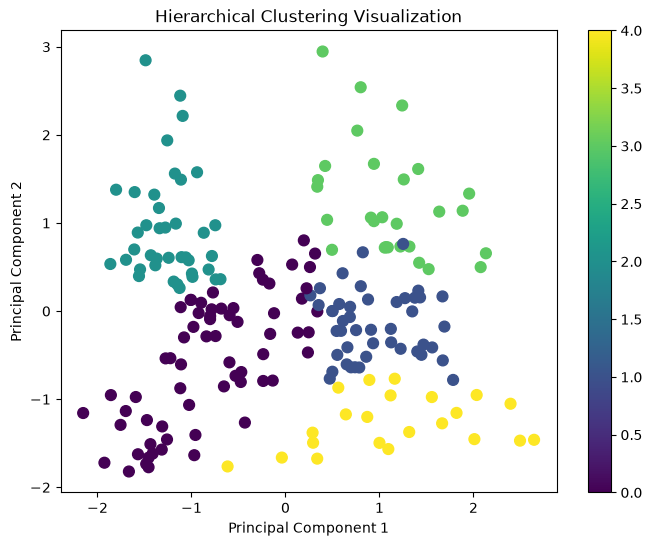

In [47]:
plt.figure(figsize=(8,6))


plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    s=60,
    cmap='viridis'
)


plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)


plt.title(
    "Hierarchical Clustering Visualization"
)


plt.colorbar()

plt.show()

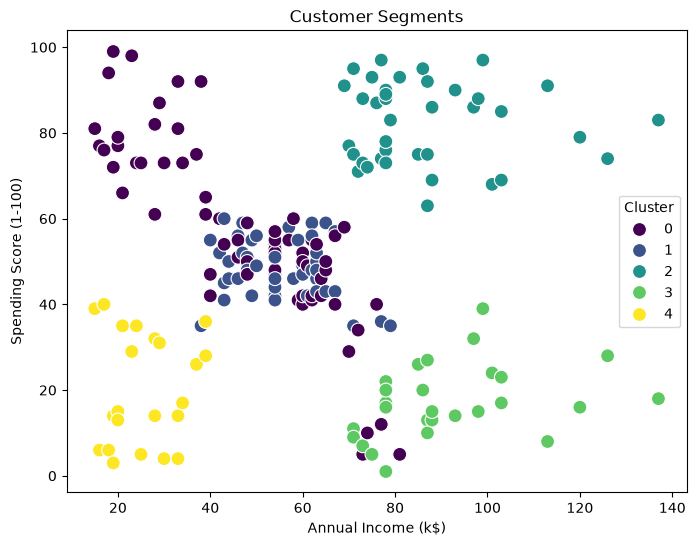

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)


plt.title(
    "Customer Segments"
)

plt.show()

In [49]:
methods=[
    'ward',
    'complete',
    'average',
    'single'
]


results=[]


for method in methods:

    model=AgglomerativeClustering(
        n_clusters=5,
        linkage=method
    )


    labels=model.fit_predict(
        X_scaled
    )


    score=silhouette_score(
        X_scaled,
        labels
    )


    results.append(
        [method,score]
    )


pd.DataFrame(
    results,
    columns=[
        "Linkage Method",
        "Silhouette Score"
    ]
)

,Linkage Method,Silhouette Score
0,ward,0.390028
1,complete,0.399982
2,average,0.409569
3,single,0.003024


In [50]:
df['Cluster'].value_counts()

Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64

In [51]:
df.groupby(
    'Cluster'
).mean()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.606061,26.560606,47.363636,56.787879
1,0.533333,56.400000,55.288889,48.355556
2,0.538462,32.692308,86.538462,82.128205
3,0.500000,43.892857,91.285714,16.678571
4,0.590909,44.318182,25.772727,20.272727


## Conclusion

- Hierarchical Clustering was successfully implemented on the Mall Customers dataset.
- Customer data was scaled before applying clustering.
- A dendrogram was used to understand the cluster hierarchy.
- The optimal number of clusters was selected using silhouette score.
- PCA visualization helped understand customer segments.
- The algorithm successfully divided customers into meaningful groups based on purchasing behavior.